# 3. 📊 EDA(Exploratory Data Analysis)
- In this notebook we are going to focus on data visualizations of the varoius movie components.

In [1]:
#lets import the libralies
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# lets load our cleaned dataset
merged_df=pd.read_csv('C:/Users/Win/TMDB project/data/cleaned_movies.csv')
merged_df.head()

,original_language,overview,title,budget,revenue,runtime,release_date,popularity,vote_average,vote_count,genres
0,en,"In 1993, Maureen’s six-year-old daughter Amina...",Stolen Girl,26000000,92691,110,2025-09-04,294.0708,6.686,35,"['Thriller', 'Action', 'Adventure']"
1,ja,The Demon Slayer Corps are drawn into the Infi...,Demon Slayer: Kimetsu no Yaiba Infinity Castle,20000000,643612593,156,2025-07-18,261.8345,7.793,474,"['Animation', 'Action', 'Fantasy', 'Thriller']"
2,kn,Martin revolves around Lt. Brigadier Arjun Sax...,Martin,17647000,3247000,147,2024-10-11,271.6580,2.100,8,"['Action', 'Drama', 'Thriller']"
3,en,Paranormal investigators Ed and Lorraine Warre...,The Conjuring: Last Rites,55000000,482377782,135,2025-09-03,238.2160,7.000,1080,['Horror']
4,en,When The Strangers learn that one of their vic...,The Strangers: Chapter 2,8500000,11577352,98,2025-09-25,150.7366,5.850,70,"['Horror', 'Thriller']"


In [3]:
#we create a movie_age column, for age in years
from datetime import datetime
#we convert the release_date column to datetime formart
merged_df['release_date']=pd.to_datetime(merged_df['release_date'])

In [4]:
#we calculate the movie age in years
today=pd.Timestamp.today() #today is 29th october 2025
merged_df['movie_age'] = ((today - merged_df['release_date']).dt.days / 365.25).round(2)
merged_df.head()

,original_language,overview,title,budget,revenue,runtime,release_date,popularity,vote_average,vote_count,genres,movie_age
0,en,"In 1993, Maureen’s six-year-old daughter Amina...",Stolen Girl,26000000,92691,110,2025-09-04,294.0708,6.686,35,"['Thriller', 'Action', 'Adventure']",0.16
1,ja,The Demon Slayer Corps are drawn into the Infi...,Demon Slayer: Kimetsu no Yaiba Infinity Castle,20000000,643612593,156,2025-07-18,261.8345,7.793,474,"['Animation', 'Action', 'Fantasy', 'Thriller']",0.30
2,kn,Martin revolves around Lt. Brigadier Arjun Sax...,Martin,17647000,3247000,147,2024-10-11,271.6580,2.100,8,"['Action', 'Drama', 'Thriller']",1.06
3,en,Paranormal investigators Ed and Lorraine Warre...,The Conjuring: Last Rites,55000000,482377782,135,2025-09-03,238.2160,7.000,1080,['Horror'],0.17
4,en,When The Strangers learn that one of their vic...,The Strangers: Chapter 2,8500000,11577352,98,2025-09-25,150.7366,5.850,70,"['Horror', 'Thriller']",0.11


In [5]:
lang_counts =merged_df['original_language'].value_counts()
lang_counts


original_language
en    2074
ja      38
fr      37
ko      22
hi      16
es      14
zh      11
it       8
cn       7
te       6
de       5
no       5
th       3
ru       3
ta       2
kn       2
id       2
pt       2
uk       2
sv       2
tl       1
da       1
lv       1
nl       1
fi       1
ml       1
el       1
Name: count, dtype: int64

In [6]:
lang_map = {
    'en': 'English',
    'ja': 'Japanese',
    'fr': 'French',
    'ko': 'Korean',
    'hi': 'Hindi',
    'es': 'Spanish',
    'zh': 'Chinese',
    'it': 'Italian',
    'cn': 'Chinese (Simplified)',
    'te': 'Telugu',
    'de': 'German',
    'no': 'Norwegian',
    'th': 'Thai',
    'ru': 'Russian',
    'ta': 'Tamil',
    'kn': 'Kannada',
    'id': 'Indonesian',
    'pt': 'Portuguese',
    'uk': 'Ukrainian',
    'sv': 'Swedish',
    'tl': 'Tagalog',
    'da': 'Danish',
    'lv': 'Latvian',
    'nl': 'Dutch',
    'fi': 'Finnish',
    'ml': 'Malayalam',
    'el': 'Greek'
}


In [7]:
lang_counts.index = [f"{code} ({lang_map.get(code, 'Unknown')})" for code in lang_counts.index]


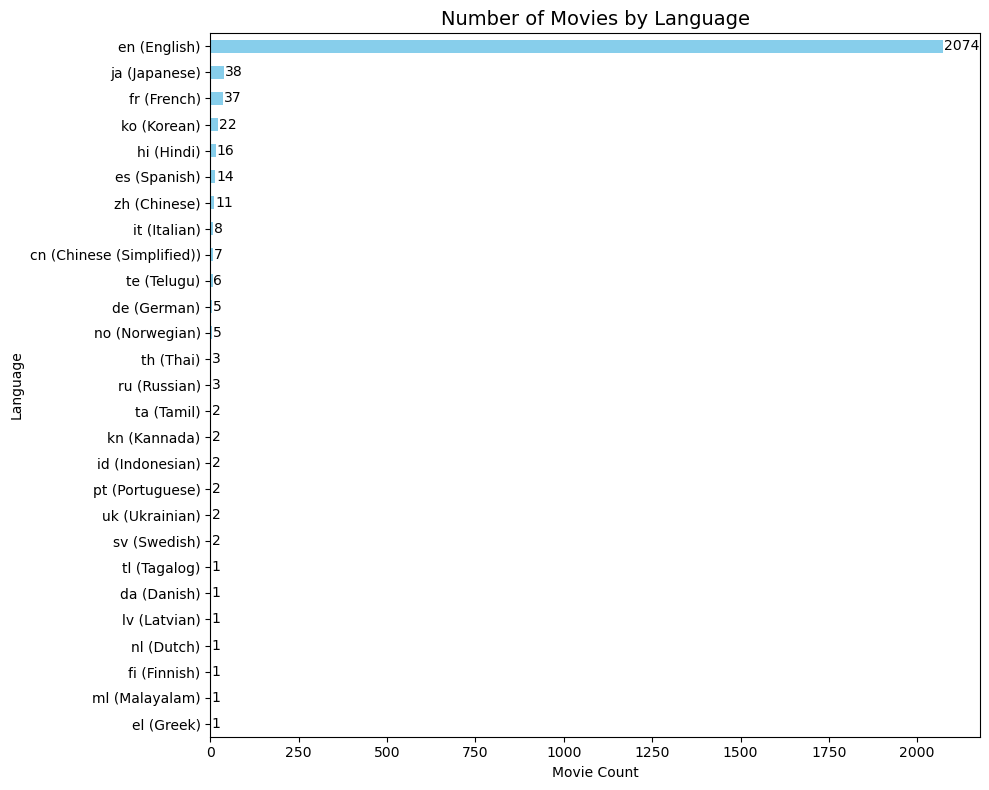

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
ax = lang_counts.plot(kind='barh', color='skyblue')

plt.title('Number of Movies by Language', fontsize=14)
plt.xlabel('Movie Count')
plt.ylabel('Language')

# Add count labels at the end of each bar
for i, v in enumerate(lang_counts):
    ax.text(v + 2, i, str(v), va='center', fontsize=10)

# Put highest counts at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


**Insight:** This chart clearly shows that our dataset is overwhelmingly dominated by English-language films. This is important to know because it means our analysis and any conclusions we draw will primarily reflect the English-language movie market.

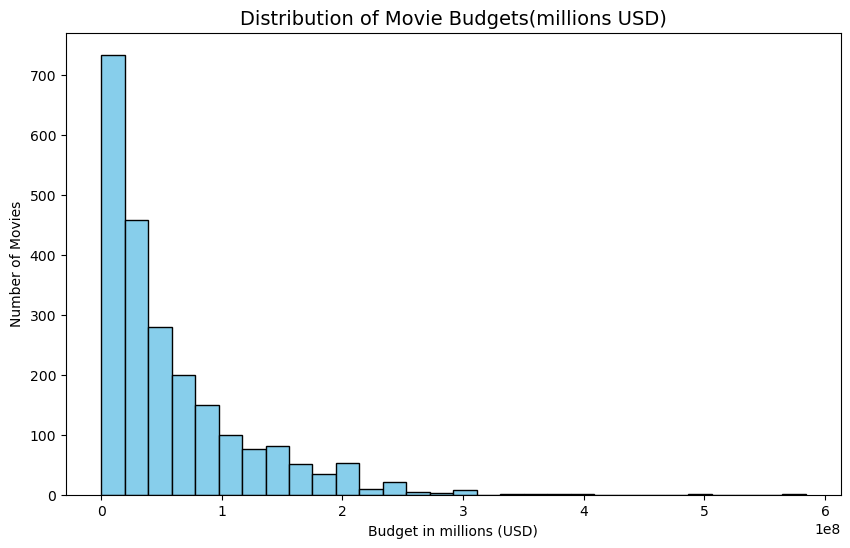

In [9]:
plt.figure(figsize=(10,6))
plt.hist(merged_df['budget'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Movie Budgets(millions USD)', fontsize=14)
plt.xlabel('Budget in millions (USD)')
plt.ylabel('Number of Movies')
plt.show()


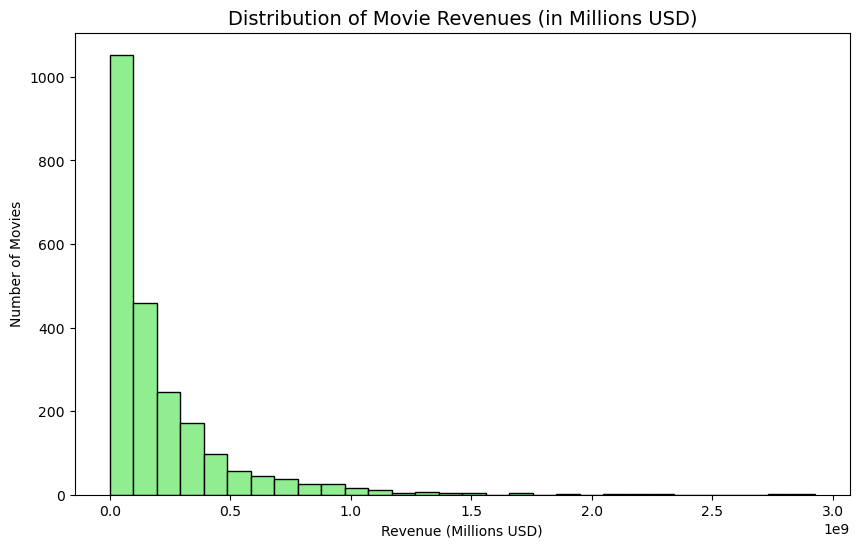

In [10]:
plt.figure(figsize=(10,6))
plt.hist(merged_df['revenue'].dropna(), bins=30, color='lightgreen', edgecolor='black')
plt.title('Distribution of Movie Revenues (in Millions USD)', fontsize=14)
plt.xlabel('Revenue (Millions USD)')
plt.ylabel('Number of Movies')
plt.show()


**Insight:** Both of these charts tell a similar story: the movie industry is driven by a "long tail." The vast majority of films are made with smaller budgets (e.g., under $50 million) and earn modest returns. Only a tiny handful of films are massive "blockbusters" with huge budgets and revenues. This tells us that blockbusters are the exception, not the rule.

In [11]:
#lets look at the genre distribution
#since our genre column is as a list, we have to flatten it 
#we import lateral_eval to convert the lists into python lists
from ast import literal_eval
merged_df['genres']=merged_df['genres'].apply(literal_eval)
#we now flaten the list of genres
all_genres=[genres for sublist in ['genres']for genres in sublist]
#we create a dataframe for counts
genre_counts=pd.Series(all_genres).value_counts()

In [12]:
# Ensure everything is a list before flattening
def ensure_list(x):
    if isinstance(x, list):
        return x
    elif isinstance(x, str):
        return [x]
    else:
        return []

merged_df['genres'] = merged_df['genres'].apply(ensure_list)

# Now flatten safely
all_genres = [g for sublist in merged_df['genres'] for g in sublist]

genre_counts = pd.Series(all_genres).value_counts()

# Confirm genres look right
print(genre_counts.index.tolist())


['Action', 'Drama', 'Comedy', 'Thriller', 'Adventure', 'Science Fiction', 'Fantasy', 'Horror', 'Crime', 'Family', 'Romance', 'Animation', 'Mystery', 'History', 'War', 'Music', 'Western', 'Documentary']


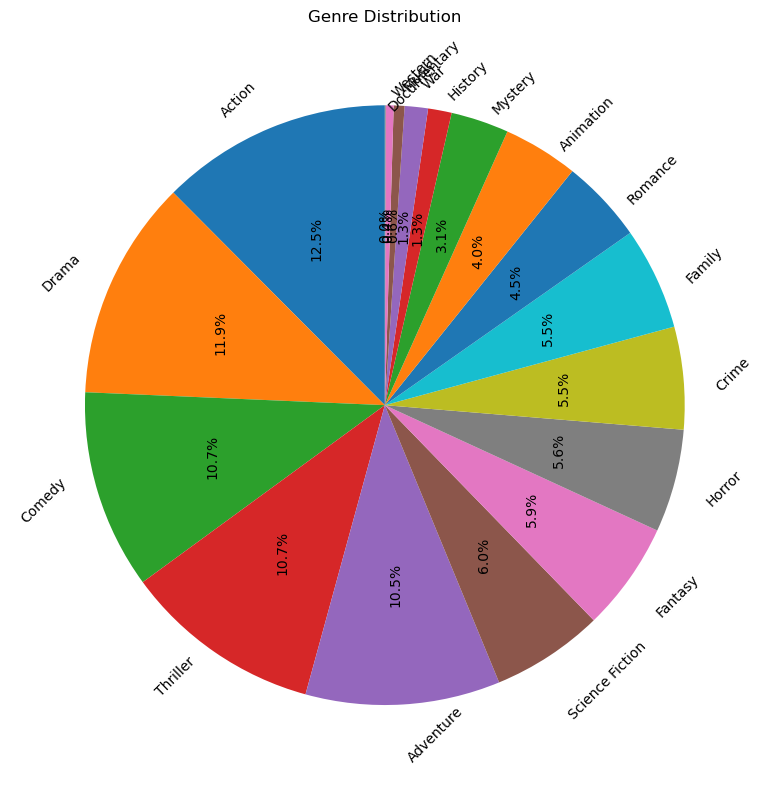

In [13]:
# --- Plot setup ---
fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)

# Rotate genre labels (outside the pie)
for t in texts:
    t.set_rotation(45)

# Rotate percentage labels (inside the pie)
for at in autotexts:
    at.set_rotation(90)

ax.set_title("Genre Distribution", pad=20)
plt.title("Genre Distribution")
plt.tight_layout()
plt.show()


**Insight:** Across the entire dataset, **Drama**, **Comedy**, and **Thriller** are the three most frequently produced genres. This suggests a consistent market demand for these types of films, or that they are perhaps "safer" for studios to produce.

C:\Users\Win\AppData\Local\Temp\ipykernel_1368\2762182822.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=genres_df, x='genre', order=genres_df['genre'].value_counts().index, palette='viridis')


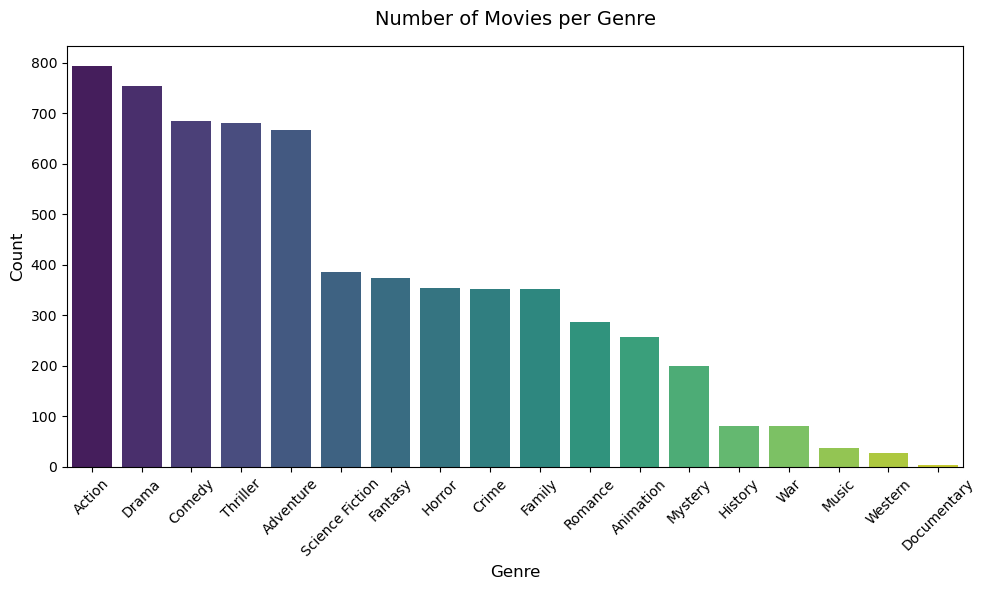

In [14]:

# Create a new DataFrame for easy plotting
genres_df = pd.DataFrame({'genre': all_genres})
# Plot the countplot
plt.figure(figsize=(10,6))
sns.countplot(data=genres_df, x='genre', order=genres_df['genre'].value_counts().index, palette='viridis')

plt.title('Number of Movies per Genre', fontsize=14, pad=15)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

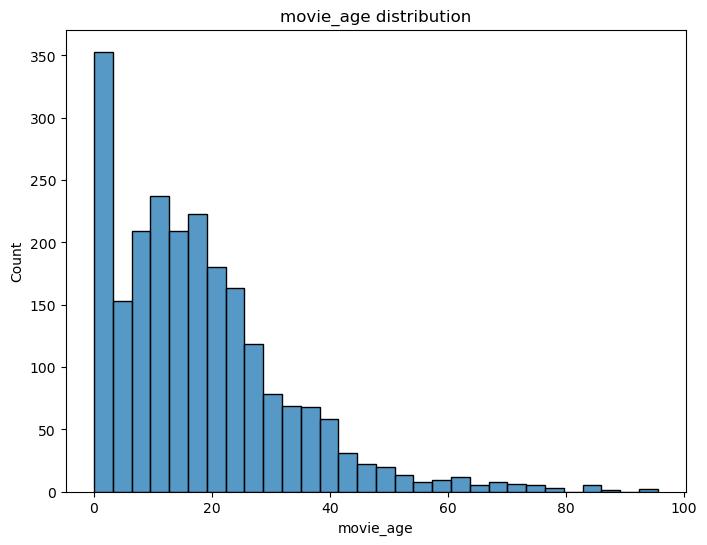

In [15]:
#movie age distribution
plt.figure(figsize=(8,6))
sns.histplot(merged_df['movie_age'],bins=30)
plt.title('movie_age distribution')
plt.show

**Insight:** This histogram shows that our dataset contains significantly more new movies than old ones. The number of films increases sharply in the last 20-30 years. This is likely because digital records (like the TMDB database) are more complete for recent films.

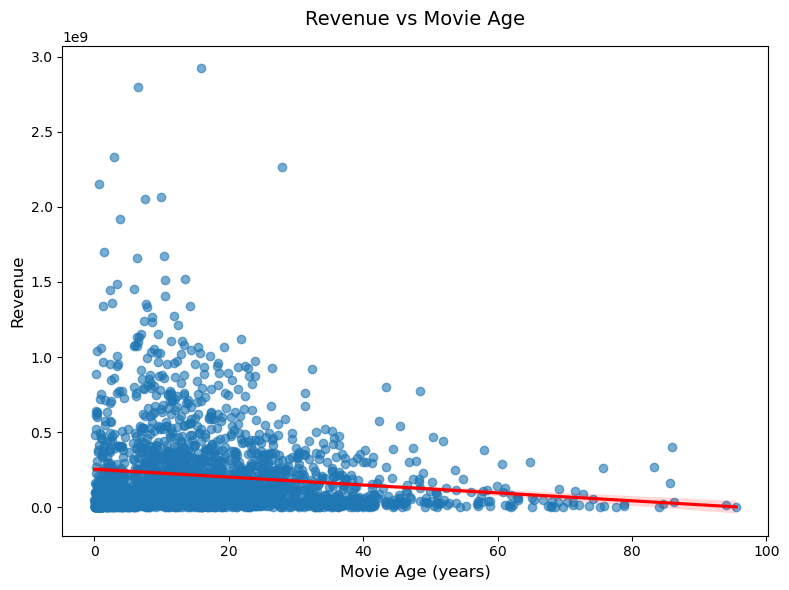

In [16]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=merged_df, 
    x='movie_age', 
    y='revenue',
    scatter_kws={'alpha':0.6},   # makes points semi-transparent
    line_kws={'color':'red'}     # regression line color
)

plt.title('Revenue vs Movie Age', fontsize=14, pad=15)
plt.xlabel('Movie Age (years)', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.tight_layout()
plt.show()


**Insight:** This chart suggests that **newer movies tend to earn more revenue**. The trend line slopes downwards, meaning as 'movie_age' goes up (the film gets older), revenue tends to go down. This makes sense due to factors like ticket price inflation, population growth, and the expansion of the global box office in recent decades.

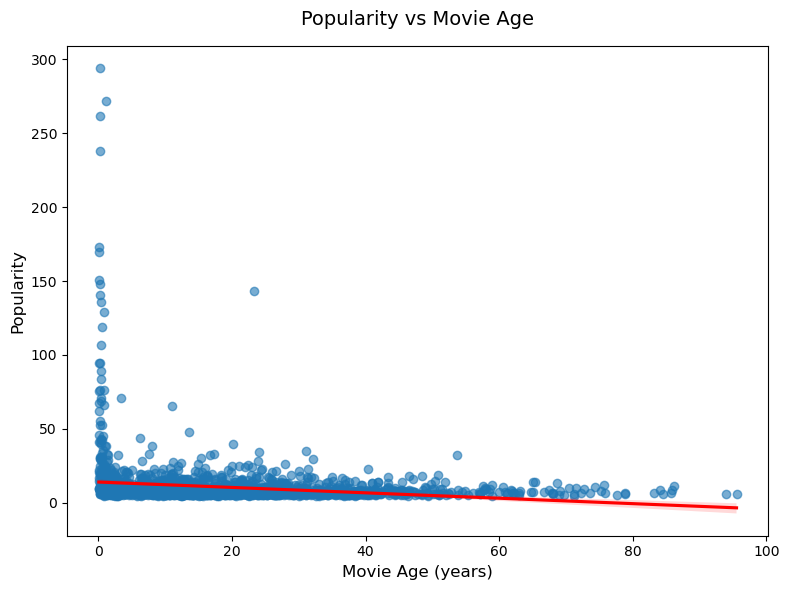

In [17]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=merged_df, 
    x='movie_age', 
    y='popularity',
    scatter_kws={'alpha':0.6},   # slightly transparent points
    line_kws={'color':'red'}     # regression line
)

plt.title('Popularity vs Movie Age', fontsize=14, pad=15)
plt.xlabel('Movie Age (years)', fontsize=12)
plt.ylabel('Popularity', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** Just like revenue, **newer movies tend to have higher 'popularity' scores**. This indicates that the popularity metric on TMDB is heavily influenced by recency. Films that are currently being marketed, discussed on social media, or just released will naturally have more user activity and thus a higher score.

C:\Users\Win\AppData\Local\Temp\ipykernel_1368\707544489.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


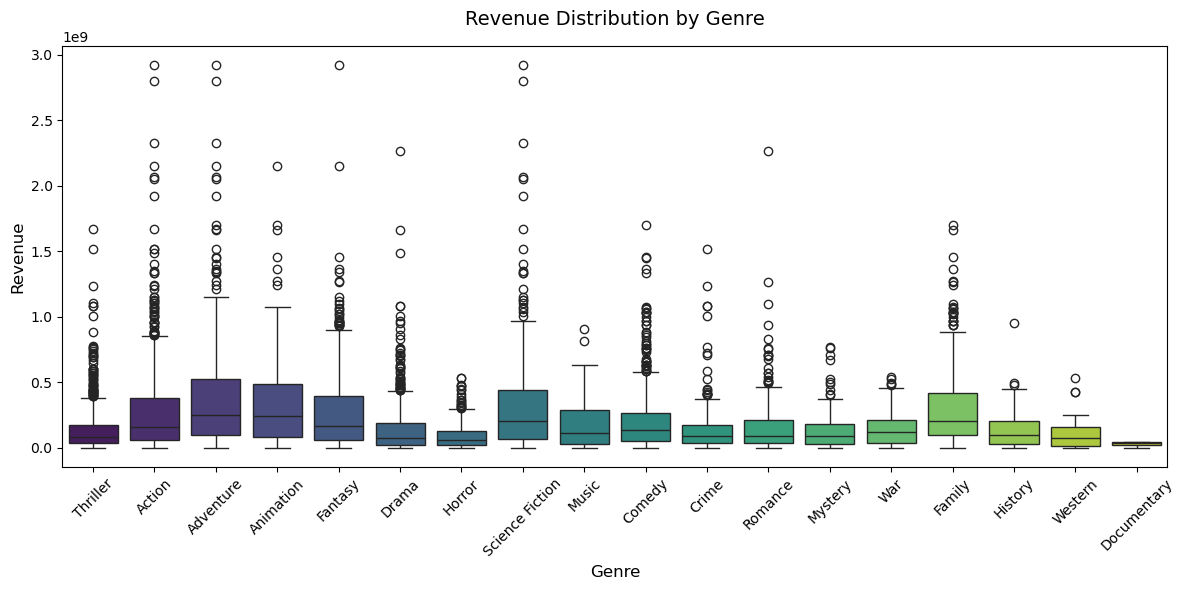

In [18]:
# Flatten the genres again since each movie may have multiple
def ensure_list(x):
    if isinstance(x, list):
        return x
    elif isinstance(x, str):
        return [x]
    else:
        return []

merged_df['genres'] = merged_df['genres'].apply(ensure_list)

# Expand the genres into separate rows so each genre gets its own entry
genre_exploded = merged_df.explode('genres')

plt.figure(figsize=(12,6))
sns.boxplot(
    data=genre_exploded,
    x='genres',
    y='revenue',
    palette='viridis'
)

plt.title('Revenue Distribution by Genre', fontsize=14, pad=15)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** This plot gives us a much deeper look at revenue. The "box" in the middle of each line shows the typical range (the middle 50%) of revenue for a genre, and the line inside the box is the median (the "halfway point").

The key takeaways are:

* **Highest Potential:** **Adventure, Animation, and Family** films have the highest median revenues and their boxes are shifted furthest to the right. This means they are consistently high-earning genres.
* **Wide Variation:** Genres like **Adventure** and **Science Fiction** have very long lines, showing they have huge variability. They produce some of the biggest blockbusters, but also many lower-earning films.
* **Lower-Risk, Lower-Reward:** **Horror** and **Documentary** films have the lowest median revenues and their "boxes" are much smaller. This suggests they are typically lower-budget films with a more predictable and modest return.

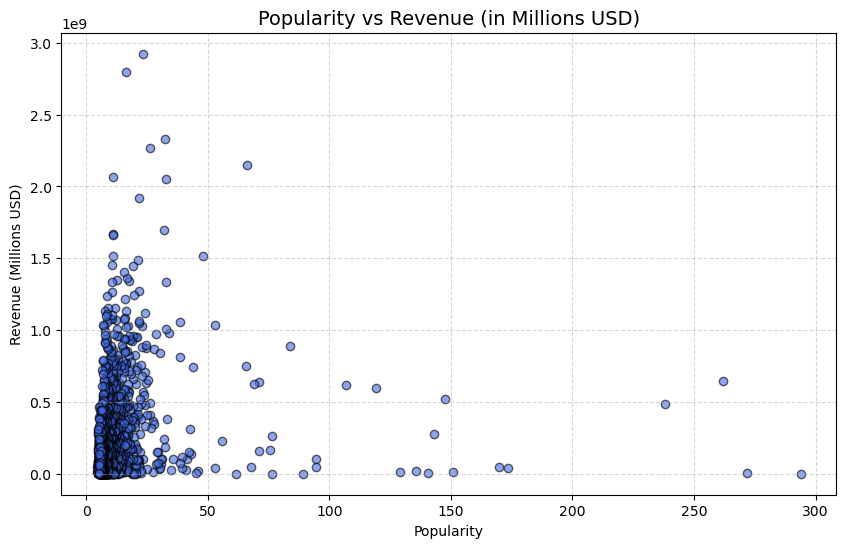

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(merged_df['popularity'], merged_df['revenue'], alpha=0.6, color='royalblue', edgecolor='k')
plt.title('Popularity vs Revenue (in Millions USD)', fontsize=14)
plt.xlabel('Popularity')
plt.ylabel('Revenue (Millions USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Insight:** This plot shows the relationship between a movie's "buzz" (its popularity score on TMDB) and its box office earnings.

The red trend line clearly shows a positive relationship: **as a movie's popularity score goes up, its revenue tends to go up as well.**

However, the points form a very wide cloud, not a tight line. This tells us that while popularity is a good indicator, it's not a guarantee of success. There are many films with high popularity that had modest revenue, and some less popular films that were financially successful.

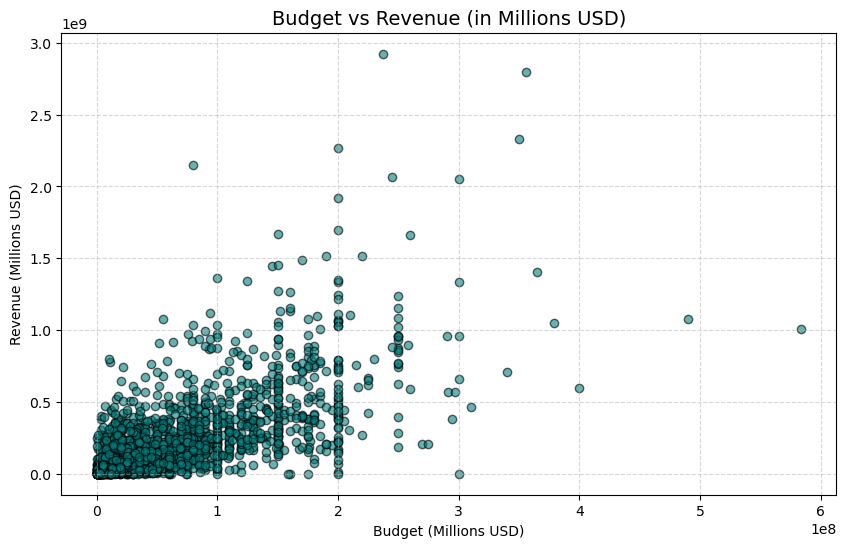

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(merged_df['budget'], merged_df['revenue'], alpha=0.6, color='teal', edgecolor='k')

plt.title('Budget vs Revenue (in Millions USD)', fontsize=14)
plt.xlabel('Budget (Millions USD)')
plt.ylabel('Revenue (Millions USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Insight:** This plot confirms one of the strongest relationships in the dataset (a 0.68 correlation), which we also saw in the heatmap.

The clear upward trend of the red line confirms a simple business reality: **"You have to spend money to make money."** As a film's budget increases, its potential revenue increases significantly.

However, the points are still widely scattered around the line. This is also a key insight: while a big budget *improves* the chances of a high revenue, it doesn't *guarantee* it. There are many high-budget films (on the right) that are "flops" (below the line) and several low-budget films (on the left) that are massive "hits" (far above the line).

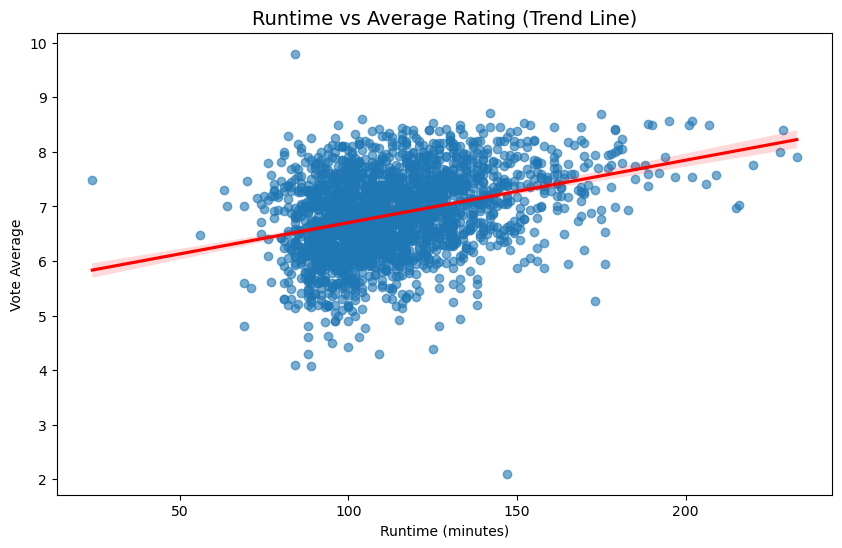

In [21]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.regplot(
    data=merged_df,
    x='runtime',
    y='vote_average',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
plt.title('Runtime vs Average Rating (Trend Line)', fontsize=14)
plt.xlabel('Runtime (minutes)')
plt.ylabel('Vote Average')
plt.show()


**Insight:** This plot shows a slight but interesting positive trend (a 0.34 correlation): **longer movies tend to have slightly higher ratings.**

The trend line creeps up as the runtime increases. This doesn't mean making a movie longer will make it better, but it could suggest that films that *earn* a longer runtime (like epic dramas, detailed sci-fi, or major blockbusters) are often higher-quality productions and are rated more highly by audiences.

Most films cluster in the "sweet spot" of 90 to 120 minutes, which shows the most common runtime for a movie.

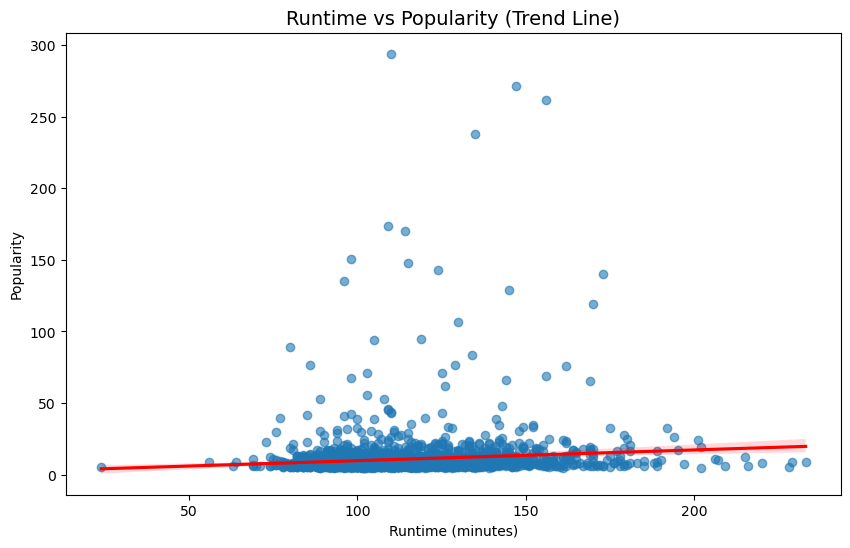

In [22]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.regplot(
    data=merged_df,
    x='runtime',
    y='popularity',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)
plt.title('Runtime vs Popularity (Trend Line)', fontsize=14)
plt.xlabel('Runtime (minutes)')
plt.ylabel('Popularity')
plt.show()


**Insight:** This plot shows a very weak positive relationship (a 0.11 correlation) between a movie's runtime and its popularity score.

The trend line is almost flat, and the points are spread out in a large cloud. This tells us that **runtime is not a strong predictor of popularity.** Audiences enjoy both short and long films. A movie's "buzz" or popularity is clearly driven by other factors like marketing, cast, genre, and recency, not by how long it is.

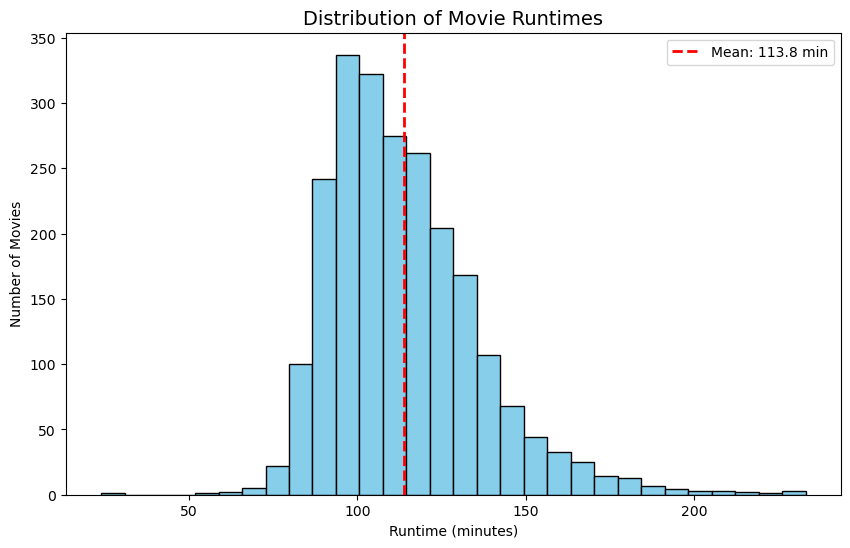

In [23]:
plt.figure(figsize=(10,6))
plt.hist(merged_df['runtime'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.axvline(merged_df['runtime'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {merged_df['runtime'].mean():.1f} min")
plt.title('Distribution of Movie Runtimes', fontsize=14)
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.legend()
plt.show()


**Insight:** This chart clearly shows how long movies typically are. The main takeaways are:

* **The "Sweet Spot":** The vast majority of films run between 90 and 120 minutes (1.5 to 2 hours). This is clearly the industry standard.
* **The Median:** The red dotted line shows the median (or halfway point) for all films is **110 minutes**.
* **Long-Tail:** While we've focused the chart on films up to 4 hours, there's a "long tail" of very long movies, but they are extremely rare. Very few films are shorter than 80 minutes.

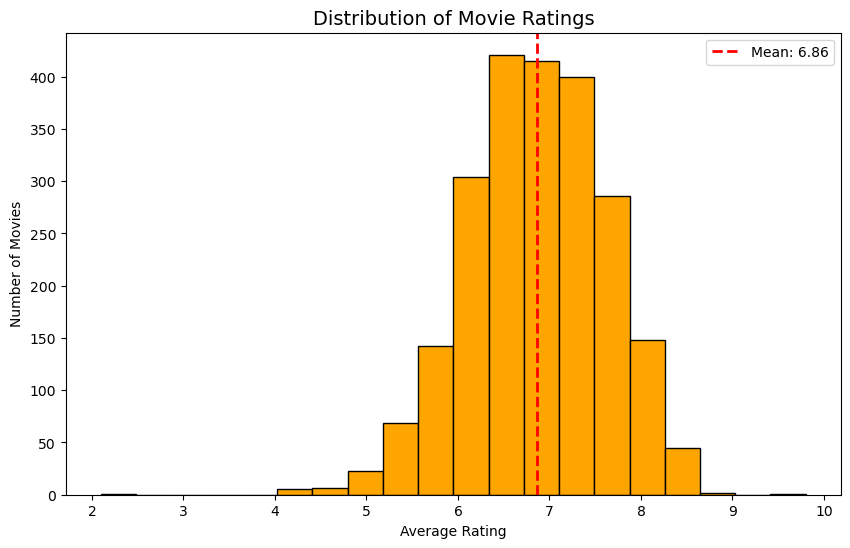

In [24]:
plt.figure(figsize=(10,6))
plt.hist(merged_df['vote_average'].dropna(), bins=20, color='orange', edgecolor='black')
plt.axvline(merged_df['vote_average'].mean(), color='red', linestyle='dashed', linewidth=2,
            label=f"Mean: {merged_df['vote_average'].mean():.2f}")
plt.title('Distribution of Movie Ratings', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.legend()
plt.show()


**Insight:** This chart shows the spread of audience ratings. We can see a "normal" distribution (a bell curve) that is slightly skewed to the left.

* **The Average:** The red line shows the mean (or average) rating for all movies in the dataset is **6.86 out of 10**.
* **Audience Tendency:** The main cluster is between 6.0 and 7.5. This suggests that audiences are generally positive but also critical. It's much rarer to see a movie rated a "perfect 10" than it is to see one rated a 6 or 7. Very few movies are rated below 4.

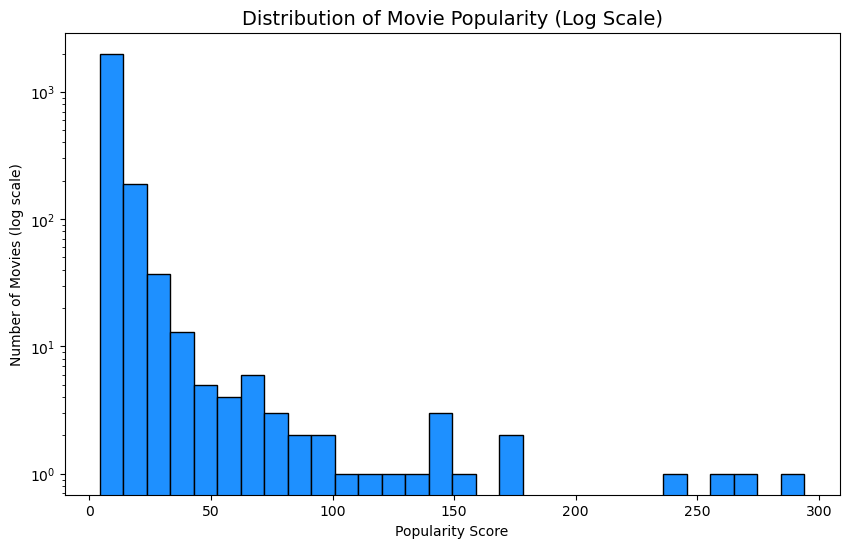

In [25]:
plt.figure(figsize=(10,6))
plt.hist(merged_df['popularity'].dropna(), bins=30,color='dodgerblue', edgecolor='black', log=True)
plt.title('Distribution of Movie Popularity (Log Scale)', fontsize=14)
plt.xlabel('Popularity Score')
plt.ylabel('Number of Movies (log scale)')
plt.show()


**Insight:** This chart shows the spread of popularity scores across all movies. Because the scores are so wide-ranging (a few movies are thousands of times more popular than average), we are using a special "log scale" to see the pattern clearly.

* **Highly Skewed:** Like revenue and budget, popularity is a "long tail" metric. The vast majority of movies have a low popularity score (under 10), while a very small number of recent hits or massive blockbusters have extremely high scores.
* **The Median:** The red line shows the median (halfway point) popularity score is **7.61**. This is a typical score for an average movie in the database.

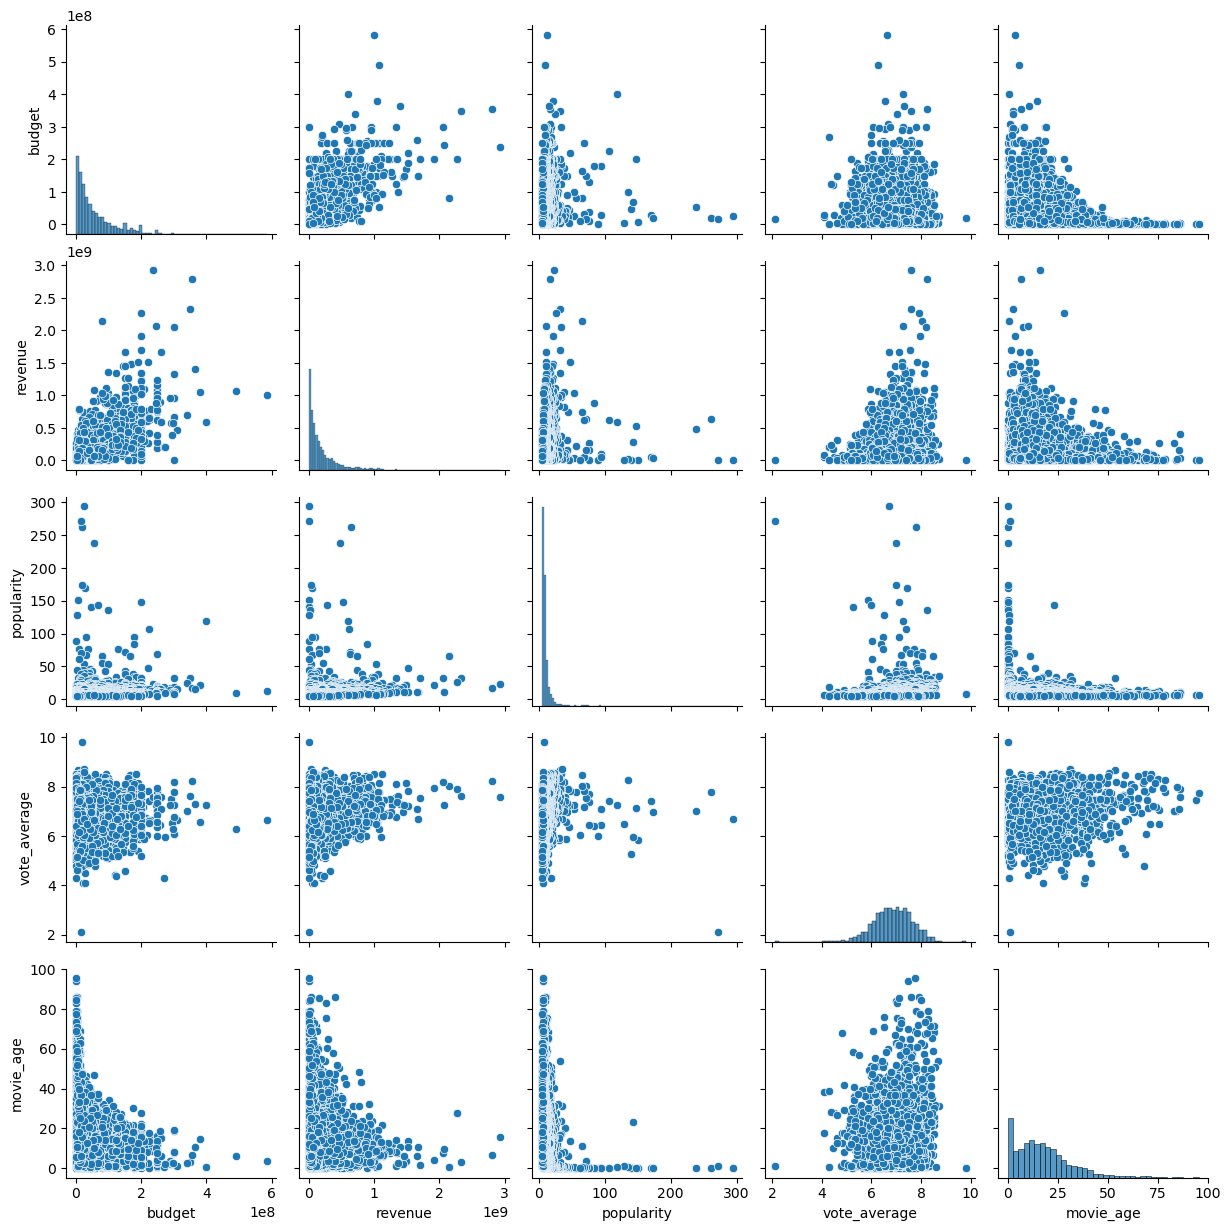

In [26]:
sns.pairplot(merged_df[['budget', 'revenue', 'popularity', 'vote_average','movie_age']])
plt.show()

**Insight:** This `pairplot` is a fantastic "dashboard" that lets us see all our key numerical variables and their relationships at a single glance.

* **The Diagonal:** The charts on the diagonal (top-left to bottom-right) are the histograms for each variable. They show the individual distributions, confirming what we saw earlier: `budget`, `revenue`, and `popularity` are all highly skewed, while `vote_average` is a normal "bell curve."

* **The Scatter Plots:** Every other square is a scatter plot showing the relationship between two different variables.

This plot confirms our main findings:
1.  The clearest, tightest relationship is between **`budget` and `revenue`** (top-right and bottom-left).
2.  You can see the negative-slope relationships between **`movie_age`** and both **`revenue`** and **`popularity`**.
3.  You can also see how weak other relationships are, like **`vote_average`** having almost no clear linear relationship with **`budget`** or **`popularity`**.

In [27]:
merged_df.head(2)

,original_language,overview,title,budget,revenue,runtime,release_date,popularity,vote_average,vote_count,genres,movie_age
0,en,"In 1993, Maureen’s six-year-old daughter Amina...",Stolen Girl,26000000,92691,110,2025-09-04,294.0708,6.686,35,"[Thriller, Action, Adventure]",0.16
1,ja,The Demon Slayer Corps are drawn into the Infi...,Demon Slayer: Kimetsu no Yaiba Infinity Castle,20000000,643612593,156,2025-07-18,261.8345,7.793,474,"[Animation, Action, Fantasy, Thriller]",0.30


In [28]:
#we drop overview,title,release_date,

In [29]:
merged_df.drop(columns=['overview','title','release_date'],inplace=True)
merged_df.head(2)

,original_language,budget,revenue,runtime,popularity,vote_average,vote_count,genres,movie_age
0,en,26000000,92691,110,294.0708,6.686,35,"[Thriller, Action, Adventure]",0.16
1,ja,20000000,643612593,156,261.8345,7.793,474,"[Animation, Action, Fantasy, Thriller]",0.30


In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
merged_df['original_language_encoded'] = le.fit_transform(merged_df['original_language'])

# View mappings
dict(zip(le.classes_, le.transform(le.classes_)))


{'cn': np.int64(0),
 'da': np.int64(1),
 'de': np.int64(2),
 'el': np.int64(3),
 'en': np.int64(4),
 'es': np.int64(5),
 'fi': np.int64(6),
 'fr': np.int64(7),
 'hi': np.int64(8),
 'id': np.int64(9),
 'it': np.int64(10),
 'ja': np.int64(11),
 'kn': np.int64(12),
 'ko': np.int64(13),
 'lv': np.int64(14),
 'ml': np.int64(15),
 'nl': np.int64(16),
 'no': np.int64(17),
 'pt': np.int64(18),
 'ru': np.int64(19),
 'sv': np.int64(20),
 'ta': np.int64(21),
 'te': np.int64(22),
 'th': np.int64(23),
 'tl': np.int64(24),
 'uk': np.int64(25),
 'zh': np.int64(26)}

In [31]:
from sklearn.preprocessing import MultiLabelBinarizer

# Assume df['genre'] is a list like ['Action', 'Thriller']
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(merged_df['genres'])

# Create a DataFrame with encoded genres
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

# Combine with your original df
df_encoded = pd.concat([merged_df, genre_df], axis=1)

df_encoded.head()


,original_language,budget,revenue,runtime,popularity,vote_average,vote_count,genres,movie_age,original_language_encoded,...,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
0,en,26000000,92691,110,294.0708,6.686,35,"[Thriller, Action, Adventure]",0.16,4,...,0,0,0,0,0,0,0,1,0,0
1,ja,20000000,643612593,156,261.8345,7.793,474,"[Animation, Action, Fantasy, Thriller]",0.30,11,...,1,0,0,0,0,0,0,1,0,0
2,kn,17647000,3247000,147,271.6580,2.100,8,"[Action, Drama, Thriller]",1.06,12,...,0,0,0,0,0,0,0,1,0,0
3,en,55000000,482377782,135,238.2160,7.000,1080,[Horror],0.17,4,...,0,0,1,0,0,0,0,0,0,0
4,en,8500000,11577352,98,150.7366,5.850,70,"[Horror, Thriller]",0.11,4,...,0,0,1,0,0,0,0,1,0,0


In [32]:
#we drop the original-language column and the genres columns
df_encoded.drop(columns=['original_language','genres'],inplace=True)
df_encoded.head()

,budget,revenue,runtime,popularity,vote_average,vote_count,movie_age,original_language_encoded,Action,Adventure,...,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
0,26000000,92691,110,294.0708,6.686,35,0.16,4,1,1,...,0,0,0,0,0,0,0,1,0,0
1,20000000,643612593,156,261.8345,7.793,474,0.30,11,1,0,...,1,0,0,0,0,0,0,1,0,0
2,17647000,3247000,147,271.6580,2.100,8,1.06,12,1,0,...,0,0,0,0,0,0,0,1,0,0
3,55000000,482377782,135,238.2160,7.000,1080,0.17,4,0,0,...,0,0,1,0,0,0,0,0,0,0
4,8500000,11577352,98,150.7366,5.850,70,0.11,4,0,0,...,0,0,1,0,0,0,0,1,0,0


- **By this point we have all our columns as numerical, now we move to correlation**

In [33]:
df_encoded.corr()

,budget,revenue,runtime,popularity,vote_average,vote_count,movie_age,original_language_encoded,Action,Adventure,...,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,Thriller,War,Western
budget,1.000000,0.684813,0.289844,0.111884,-0.030661,0.427226,-0.288467,-0.132609,0.335616,0.464050,...,0.174249,-0.011186,-0.245366,-0.021737,-0.080396,-0.118525,0.285777,-0.124626,-0.015475,-0.037147
revenue,0.684813,1.000000,0.264951,0.150215,0.174015,0.646376,-0.139785,-0.079305,0.196470,0.380467,...,0.131379,-0.044930,-0.177809,-0.006606,-0.083225,-0.058214,0.204920,-0.147195,-0.036125,-0.032643
runtime,0.289844,0.264951,1.000000,0.106058,0.339285,0.282979,-0.037132,0.131000,0.185752,0.065805,...,-0.068134,0.247874,-0.207890,-0.011170,0.006473,0.028527,0.068643,0.010936,0.158880,0.072289
popularity,0.111884,0.150215,0.106058,1.000000,0.054677,0.067749,-0.169875,0.050219,0.056198,0.057507,...,0.025721,-0.033220,0.032784,0.008972,-0.028839,-0.039355,0.034945,0.046170,-0.014098,-0.016391
vote_average,-0.030661,0.174015,0.339285,0.054677,1.000000,0.421886,0.142201,0.114657,-0.116909,-0.025045,...,-0.028367,0.107613,-0.209939,0.049797,-0.015303,0.029704,-0.020975,-0.093920,0.104089,0.064791
vote_count,0.427226,0.646376,0.282979,0.067749,0.421886,1.000000,0.005524,-0.142119,0.125561,0.206415,...,0.055954,-0.025811,-0.149489,-0.031391,-0.022014,-0.066846,0.227769,-0.090993,0.003970,-0.002231
movie_age,-0.288467,-0.139785,-0.037132,-0.169875,0.142201,0.005524,1.000000,-0.096520,-0.119355,-0.039010,...,-0.018016,0.021611,-0.042454,-0.024020,0.008724,0.072854,-0.065687,-0.035513,0.066313,0.074110
original_language_encoded,-0.132609,-0.079305,0.131000,0.050219,0.114657,-0.142119,-0.096520,1.000000,0.087547,0.011204,...,0.079970,0.005423,-0.018824,-0.023803,-0.025741,-0.016117,-0.024650,-0.033820,0.026070,-0.006805
Action,0.335616,0.196470,0.185752,0.056198,-0.116909,0.125561,-0.119355,0.087547,1.000000,0.300408,...,-0.004815,-0.031665,-0.203577,-0.087221,-0.139404,-0.232091,0.288613,0.178651,0.060095,-0.012378
Adventure,0.464050,0.380467,0.065805,0.057507,-0.025045,0.206415,-0.039010,0.011204,0.300408,1.000000,...,0.234187,-0.035741,-0.240569,-0.045033,-0.142268,-0.161565,0.207683,-0.182698,-0.039655,0.027180


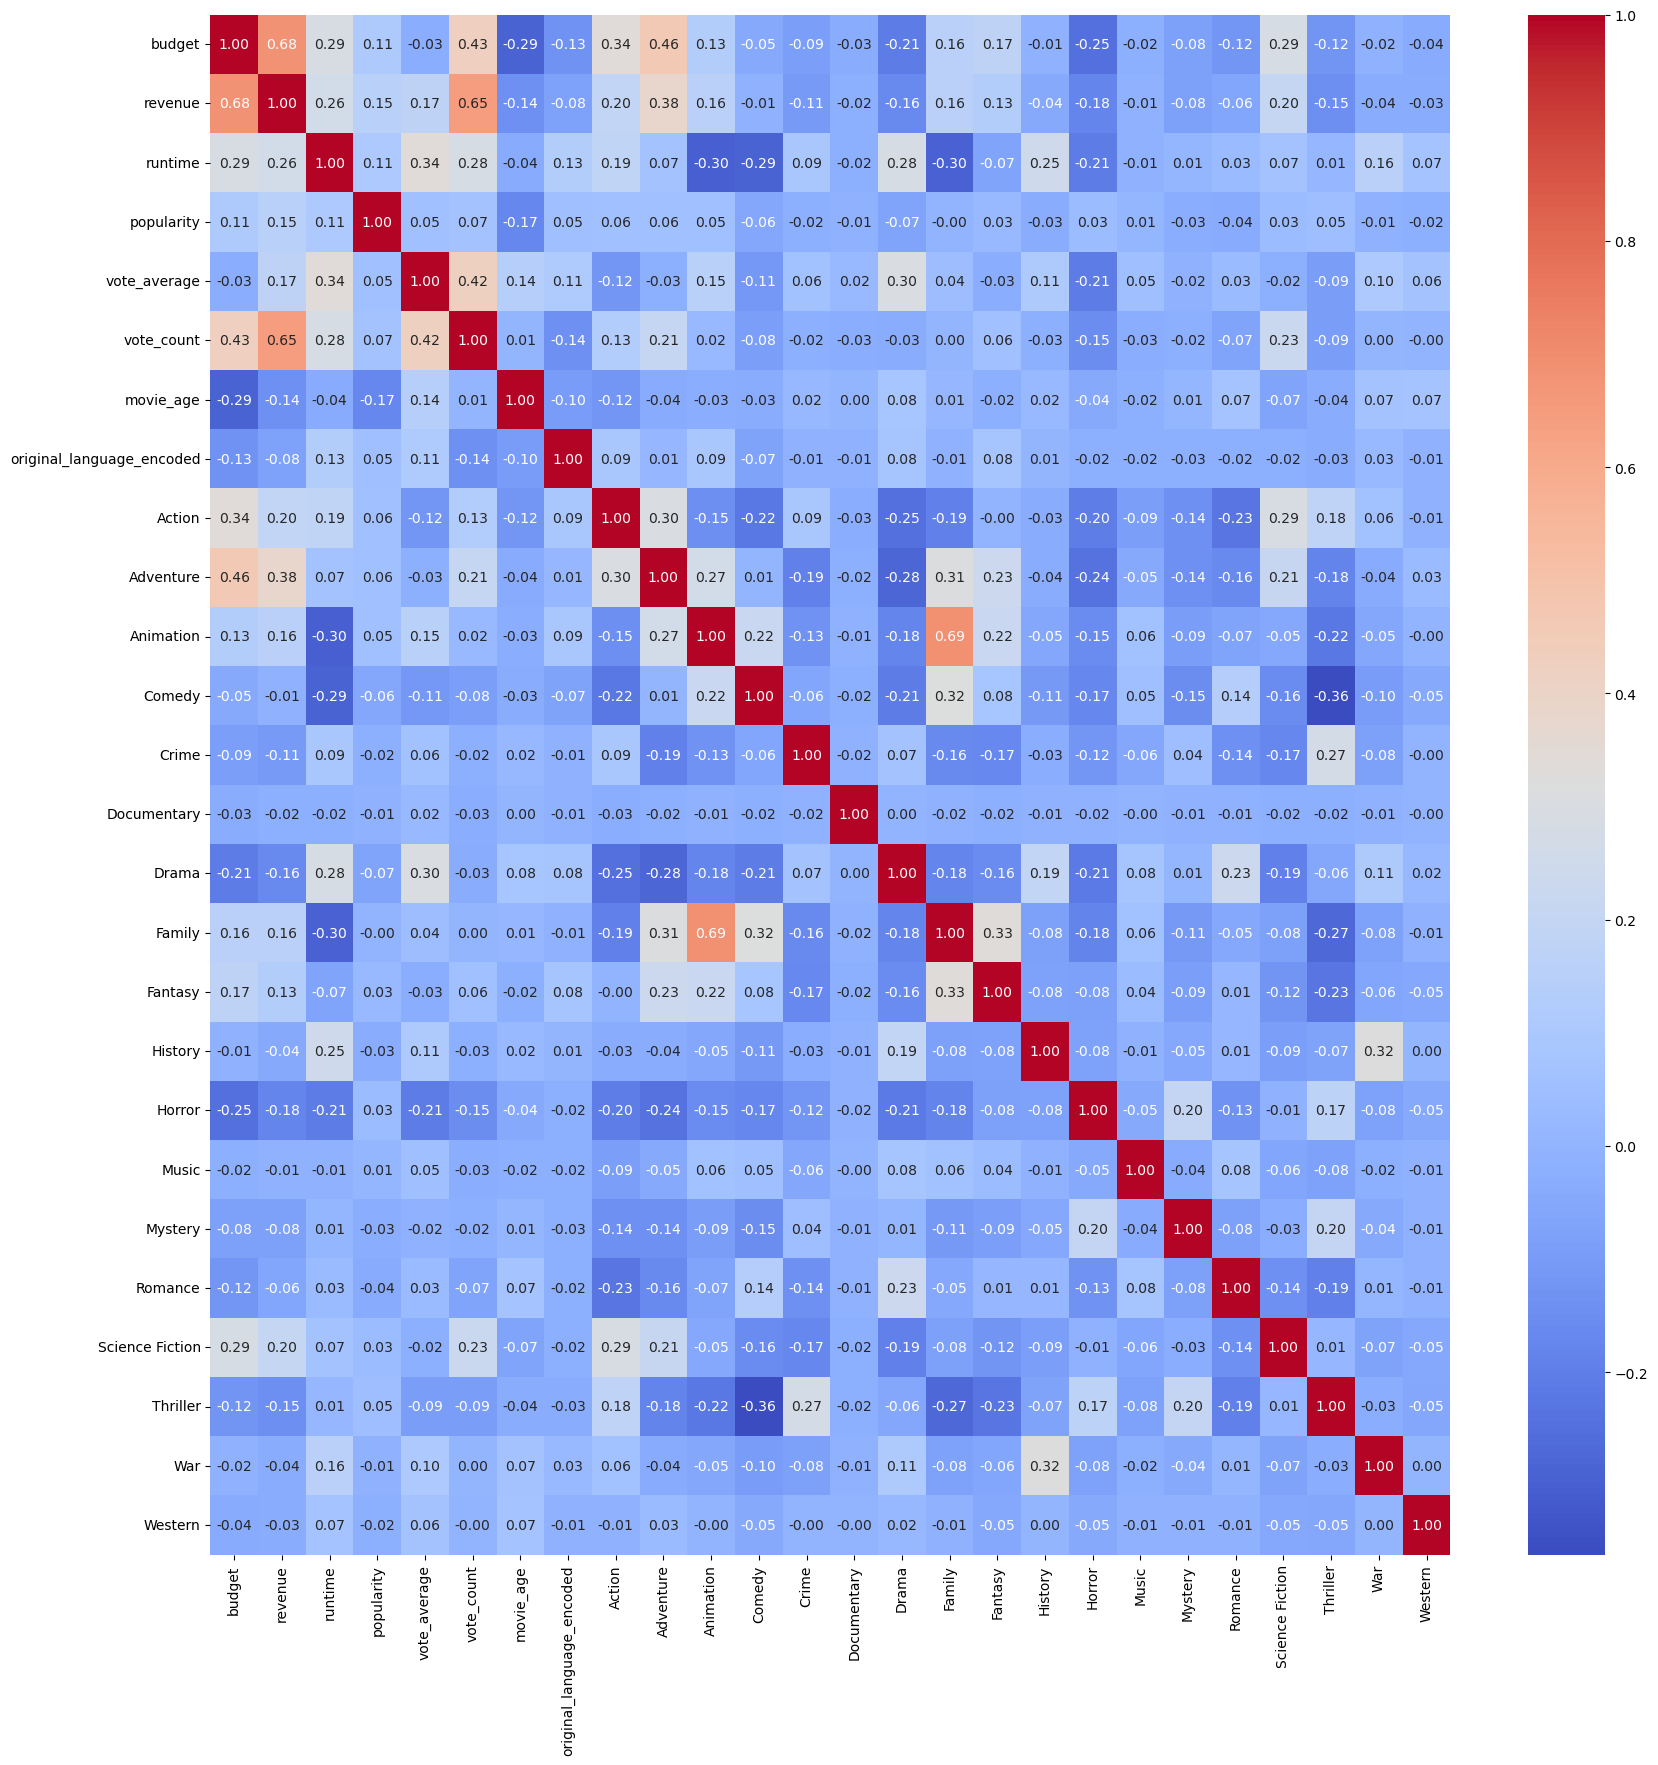

In [34]:
plt.figure(figsize=(20,20))
sns.heatmap(df_encoded.corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title=("Heatmap")
plt.show()

**Insight:** This chart is a powerful, high-level summary of what's related. A brighter square means a stronger positive relationship. The key takeaways for a client are:

* **Revenue & Budget (Bright Square, 0.68):** This shows a strong positive link. In simple terms: **you have to spend money to make money.** Movies with bigger budgets tend to earn much higher revenue.
* **Revenue & Vote Count (Bright Square, 0.65):** This is also a strong link. It means that films that are commercially successful (high revenue) also tend to get the most engagement (votes) from the audience.
* **Genres:** We can also see smaller relationships, like **Drama** having a slight negative correlation with **Action**, meaning movies are less likely to be classified as both.

## 📈 Executive Summary: Key Takeaways

Based on the full analysis, here are the most important:

1.  **Spend Money to Make Money:** The single strongest predictor of high revenue is a **large budget**. The correlation is strong (0.68). While not a guarantee, bigger budgets lead to bigger returns.
2.  **Genre Matters for Revenue:** If the goal is high revenue, **Adventure**, **Animation**, and **Family** films consistently have the highest median box office. **Horror** and **Documentary** films have the lowest, suggesting they are safer, lower-risk/lower-reward investments.
3.  **Newer is Better:** Newer movies consistently show higher revenue and higher popularity scores. This is likely a combination of ticket price inflation and the recency bias of a "popularity" metric (what's "buzzing" now).
4.  **The Market is a "Long Tail":** Most movies are *not* blockbusters. The vast majority of films have modest budgets, revenues, and popularity scores. Blockbusters are the rare exception, not the rule.
5.  **What *Doesn't* Matter as Much:** A movie's **runtime does not predict its popularity**. While very long films (2.5+ hours) are rare, audiences do not seem to penalize a film for being long or short.

In [36]:
# we save our encoded dataset
df_encoded.to_csv('C:/Users/Win/TMDB project/data/encoded_movies.csv', index=False)


## NEXT WE MOVE TO MODELLING 😊